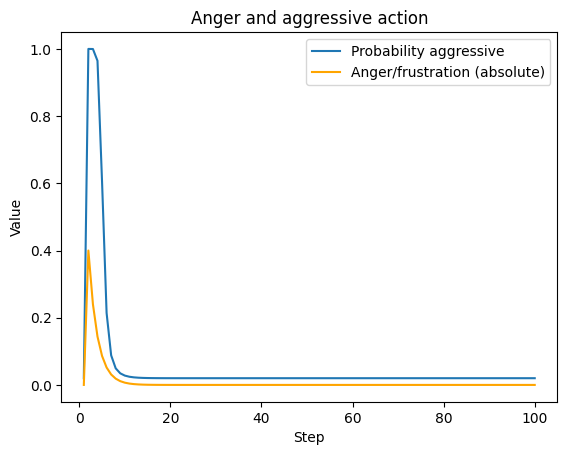

In [52]:
import model
import importlib
importlib.reload(model)
import pandas as pd
import seaborn as sns

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.options.display.float_format = "{:.3f}".format

init_variables = {
    "V": 0,
    "M_A": 0,
    # TODO: M_A at t=1 is actually not defined. but setting 0 is justified?

    # prior tendencies for friendly behavior
    "theta_F_w0": 3.892,  # should yield around 95% friendly in the beginning
    "theta_F_w1": 0,

    # prior tendencies for aggressive behavior
    "theta_A_w0": 0,
    "theta_A_w1": -50,

    # Some variables will be calculated in the model
    # or received from the environment
    "p_A": None,
    "p_F": None,
    "r": None,
    "rpe": None,
}

init_variables["theta_F"] = init_variables["theta_F_w0"] + init_variables[
    "theta_F_w1"
]

init_variables["theta_A"] = init_variables["theta_A_w0"] + init_variables[
    "theta_F_w1"
]

init_parameters = {
    # parameter for the exponential moving average of anger
    "lambda_A": 0.60,

    # controllability
    "C": 1
}

starter_model = model.IrritabilityModel(init_variables=init_variables,
                                        init_parameters=init_parameters)

n_ticks = 100

for _ in range(n_ticks):
    starter_model.step()

aggressive_counter = starter_model.agents[0]._variables["aggressive_counter"]
aggressive_percent = aggressive_counter / n_ticks

# print(aggressive_counter)

# Extract MoneyModel data in a Pandas dataframe
data = starter_model.datacollector.get_agent_vars_dataframe()

g = sns.lineplot(data=data,
                 y="p_A",
                 x="Step",
                 label="Probability aggressive")

g = sns.lineplot(data=data,
                 y=data["M_A"].abs(),
                 x="Step",
                 color="Orange",
                 label="Anger/frustration (absolute)")

g.set(title="Anger and aggressive action",
      ylabel="Value");

# display(data)
